# RetailPulse — Exploratory Analysis Notebook

This notebook walks through the RetailPulse pipeline interactively, calling the
same `src/` modules used by `python src/main.py`, so every number and chart
here matches the production pipeline exactly.

**Dataset**: Online Retail II (UK-based online retailer), ~525K raw transactions
spanning December 2009 to December 2010.

**Flow**: load → clean → SQL modeling layer → sales/product/country analysis →
RFM segmentation (rule-based + K-Means) → cohort retention → revenue forecasting.

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))

from src import cleaning, cohort, config, data_loader, database, forecasting, rfm, sales_analysis

PROCESSED = config.PROCESSED_DIR
def show(filename):
    display(Image(filename=str(PROCESSED / filename)))

## 1. Load raw data

In [2]:
raw_df = data_loader.load_raw_data()
print(raw_df.shape)
raw_df.head()

(525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Clean transactions

Removes exact duplicates, cancelled invoices (Invoice starting with "C"),
and negative-quantity/negative-price records, then derives `Revenue` and
`YearMonth`.

In [3]:
df, cleaning_log = cleaning.clean_transactions(raw_df)
product_df = cleaning.build_product_df(df)
cleaning_log

{'raw_shape': (525461, 8),
 'duplicates_removed': 6865,
 'cancelled_transactions_removed': 10182,
 'negative_quantity_removed': 2121,
 'negative_price_removed': 3,
 'zero_price_transactions': 1560,
 'missing_customer_id': 105343,
 'missing_description': 1101,
 'clean_shape': (506290, 8)}

## 3. SQL modeling layer

Clean transactions are loaded into a local SQLite database
(`data/processed/retail.db`) using the schema in `sql/01_schema.sql`.
RFM scoring, cohort activity, and monthly KPIs are then computed with
window-function SQL queries (`NTILE`, `LAG`, `RANK`) in `sql/`.

In [4]:
database.build_database(df)
sql_rfm = database.run_sql_file("02_rfm.sql")
sql_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Spend_Rank
0,18102,0,89,349164.35,5,5,5,15,1
1,14646,9,78,248396.50,5,5,5,15,2
2,14156,6,102,196549.74,5,5,5,15,3
3,14911,0,205,152121.22,5,5,5,15,4
4,13694,8,94,131443.19,5,5,5,15,5


## 4. Sales, product & country performance

In [5]:
simple_tables = sales_analysis.simple_sales_tables(df, product_df)
monthly_kpis = sales_analysis.monthly_kpi_analysis()
sales_analysis.product_performance_analysis(df)
country_analysis = sales_analysis.country_performance_analysis(df)
monthly_kpis

,YearMonth,Orders,Customers,Quantity_Sold,Total_Revenue,Revenue_Growth_Pct,Revenue_Rank
0,2009-12,1839,955,444341,822483.950,NaN,5
1,2010-01,1205,720,395234,651155.112,-20.83,10
2,2010-02,1281,774,391860,551504.726,-15.30,12
3,2010-03,1770,1057,530314,830915.261,50.66,4
4,2010-04,1512,942,385747,678875.252,-18.30,8
5,2010-05,1642,966,424009,657705.500,-3.12,9
6,2010-06,1719,1041,413723,749537.310,13.96,6
7,2010-07,1584,928,358590,648810.270,-13.44,11
8,2010-08,1511,911,521762,695251.910,7.16,7
9,2010-09,1911,1145,592615,921696.991,32.57,3


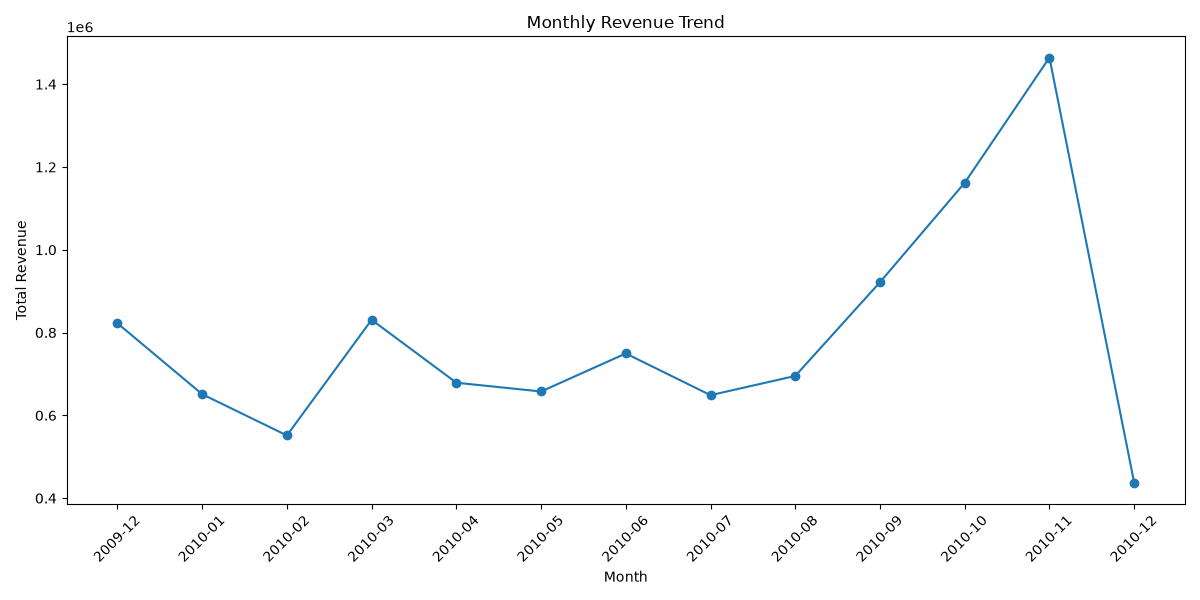

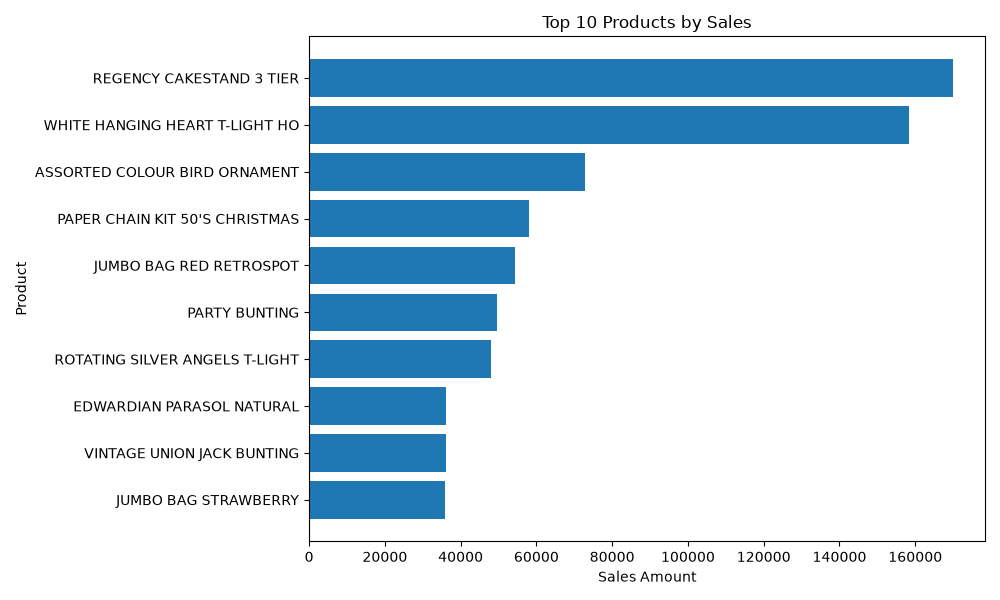

In [6]:
show("monthly_revenue_trend.png")
show("top_10_products.png")

## 5. RFM segmentation (rule-based quintiles)

Recency/Frequency/Monetary scored 1–5 via quantiles, summed into an
RFM score, then bucketed into five business-named segments.

In [7]:
rfm_base = rfm.compute_rfm(df)
rfm_segments = rfm.add_rule_based_segments(rfm_base)
segment_performance = rfm.segment_performance_report(rfm_segments)
rfm.purchase_behavior_by_segment(rfm_segments)
sales_analysis.order_value_analysis(df, rfm_segments)
segment_performance

,Customers,Total_Revenue,Average_Revenue,Average_Frequency,Average_Recency,Revenue_Percentage,Customer_Percentage
Customer_Segment,,,,,,,
VIP / Champions,920,5950360.09,6467.78,12.22,15.72,67.63,21.33
Loyal Customers,1026,1723810.70,1680.13,4.10,47.79,19.59,23.78
Potential Loyalists,1126,797276.74,708.06,2.07,85.00,9.06,26.10
At Risk,701,228560.28,326.05,1.25,143.86,2.60,16.25
Lost / Hibernating,541,98225.93,181.56,1.01,247.11,1.12,12.54


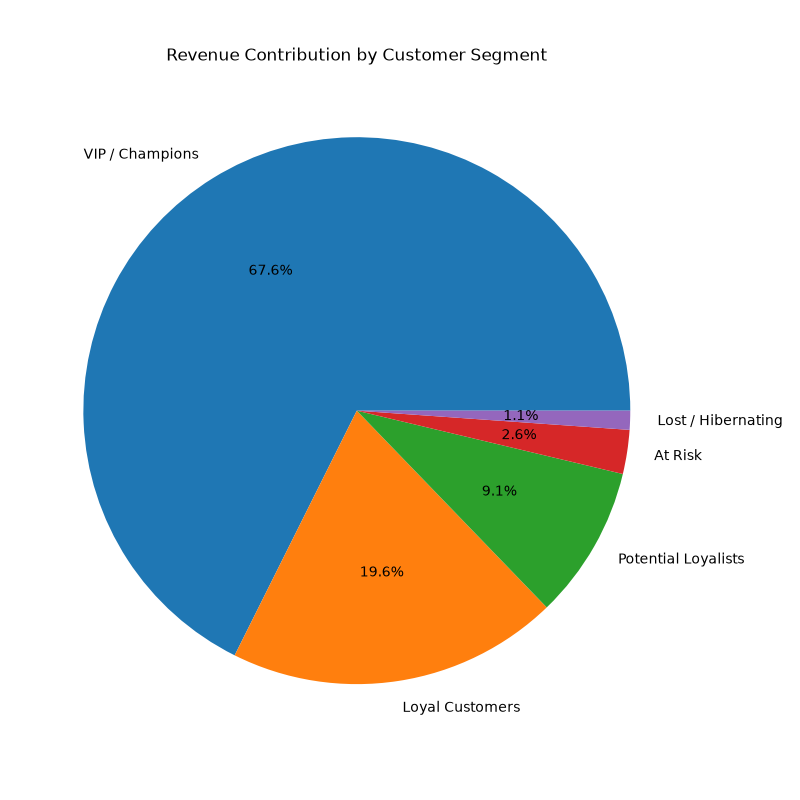

In [8]:
show("revenue_contribution_by_segment.png")

## 6. K-Means clustering segmentation

An alternative, data-driven segmentation: standardize Recency/Frequency/
Monetary, sweep k=2..8 K-Means fits, pick k via the elbow method (max
distance from the chord connecting the first and last inertia points),
then label clusters by value (Champions/Loyal) and staleness (At Risk/Lost).

In [9]:
kmeans_result, kmeans_profile, k = rfm.kmeans_segmentation(rfm_base)
print(f"Selected k = {k}")
kmeans_profile

Selected k = 4


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
KMeans_Segment,,,,,
At Risk,3204,43.03,4.46,1710.65,5480922.70
Loyal Customers,56,14.91,47.02,28896.42,1618199.33
Champions,5,5.60,113.60,215535.00,1077675.00
Lost,1049,243.09,1.66,592.41,621436.71


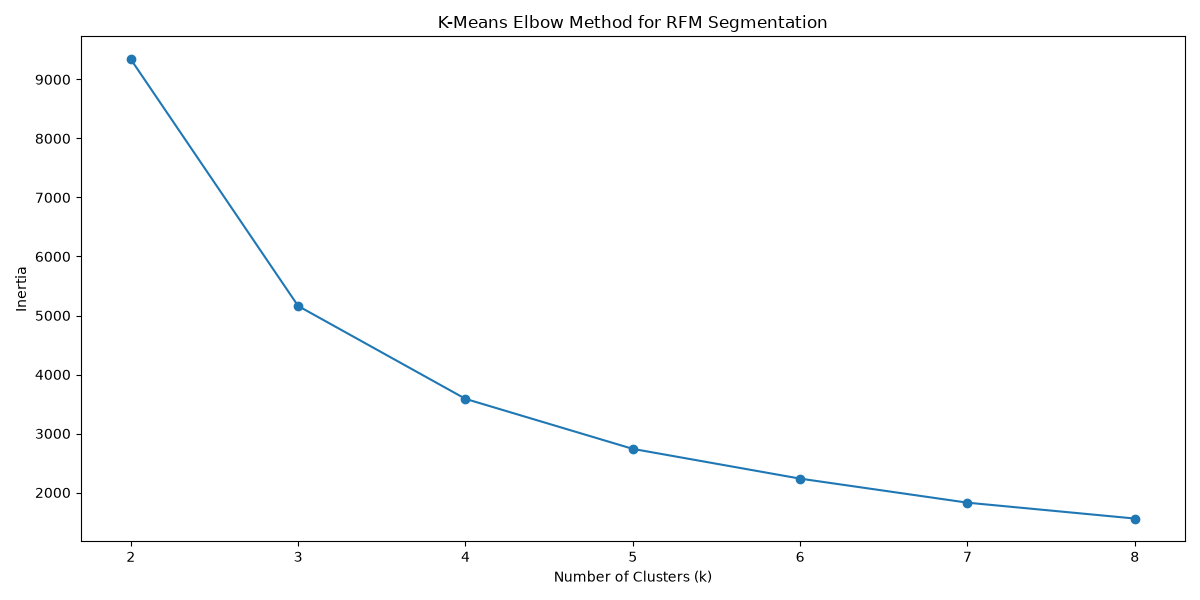

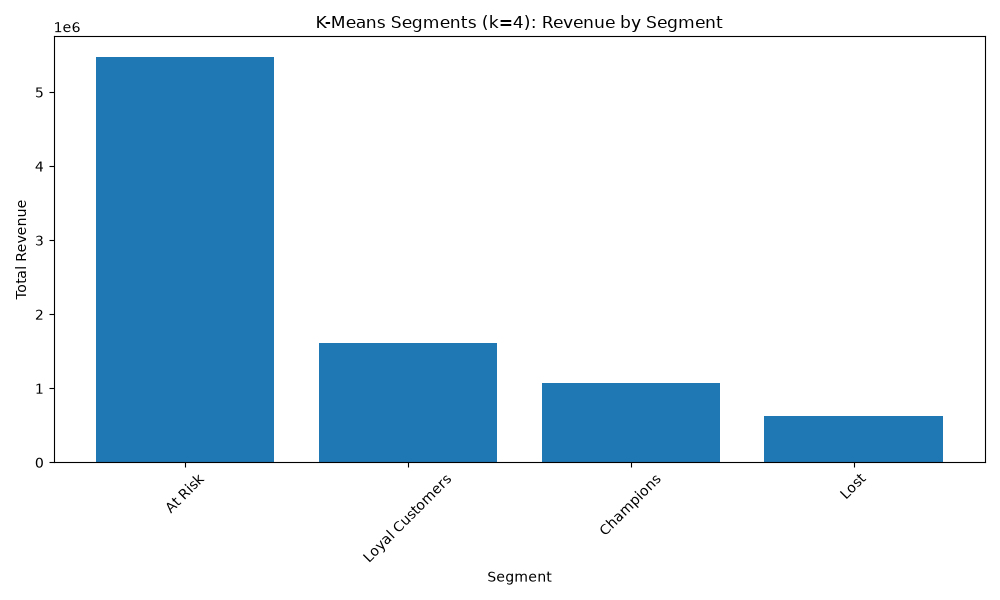

In [10]:
show("rfm_kmeans_elbow.png")
show("rfm_kmeans_segment_revenue.png")

## 7. Cohort retention analysis

Each customer is assigned to a cohort by their first-purchase month.
The heatmap shows what percentage of each cohort is still buying N
months after their first purchase — a much stricter test of loyalty
than the simple repeat-vs-one-time split.

In [11]:
retention_summary = cohort.repeat_customer_analysis(df, rfm_segments)
cohort_result = cohort.cohort_retention_matrix()
print(f"Repeat customer rate: {retention_summary['repeat_percentage']}%")
print(f"Average month-1 cohort retention: {cohort_result['avg_month1_retention']:.2f}%")
cohort_result["matrix"].head()

Repeat customer rate: 67.06%
Average month-1 cohort retention: 20.52%


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,24.82
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,9.92,NaN
2010-02,100.0,23.67,22.34,28.99,24.47,19.95,19.15,28.46,25.27,27.39,7.18,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,6.80,NaN,NaN,NaN,NaN


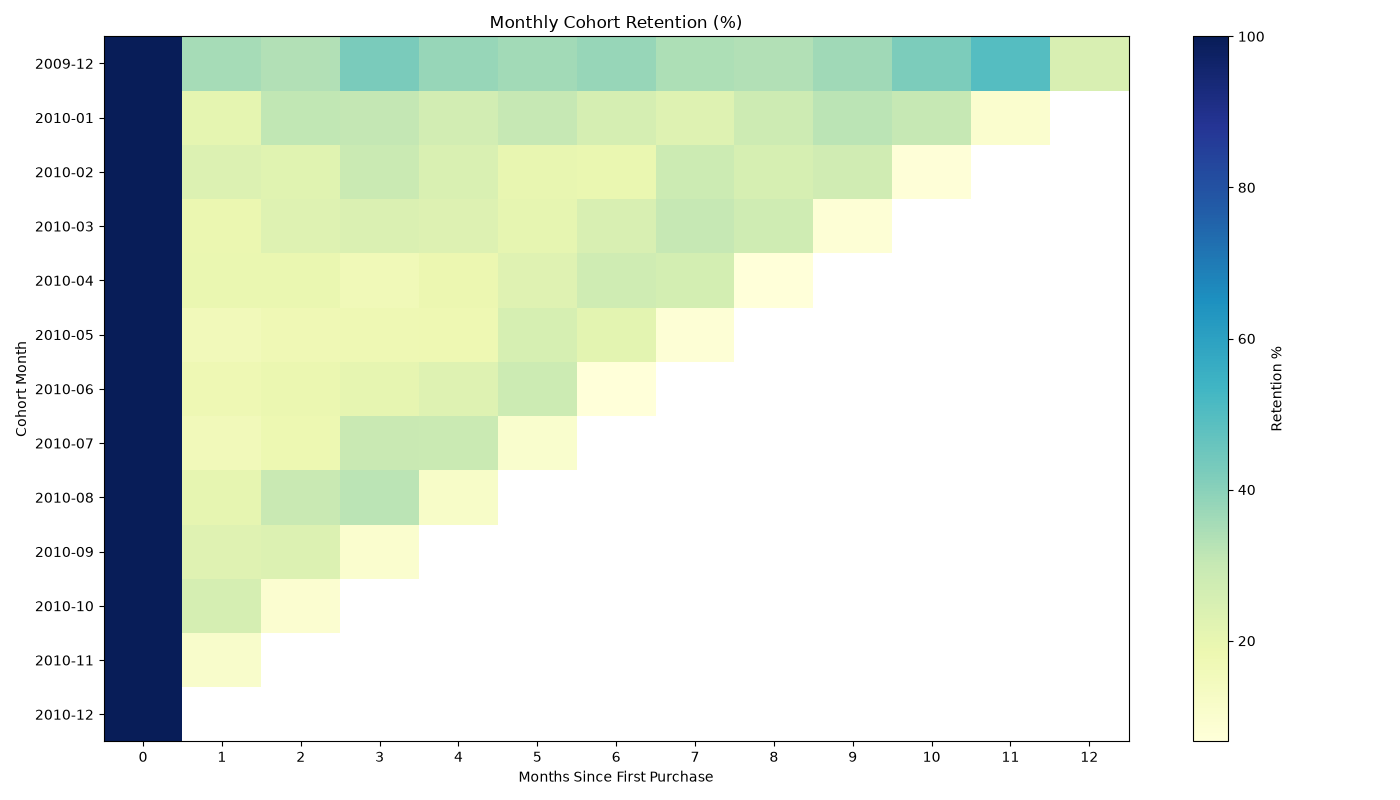

In [12]:
show("cohort_retention_heatmap.png")

## 8. Revenue forecasting

Holt-Winters exponential smoothing (additive trend, no seasonal term —
only ~12 clean months of history, not enough to fit a yearly seasonal
cycle). The trailing month is excluded automatically when the raw data
cuts off mid-month (true here: the source file stops on 2010-12-09),
since an incomplete month would otherwise look like a demand crash.
Backtested against the last 3 actual months before refitting on the
full series for the forward forecast.

In [13]:
forecast_result = forecasting.forecast_revenue(monthly_kpis, max_invoice_date=df["InvoiceDate"].max())
print(f"Excluded partial month: {forecast_result['excluded_partial_month']}")
print(f"Backtest MAPE: {forecast_result['mape']:.2f}%")
forecast_result["forecast"]

Excluded partial month: 2010-12


Backtest MAPE: 48.43%


2010-12-01    1.692625e+06
2011-01-01    1.957222e+06
2011-02-01    2.221818e+06
Freq: MS, dtype: float64

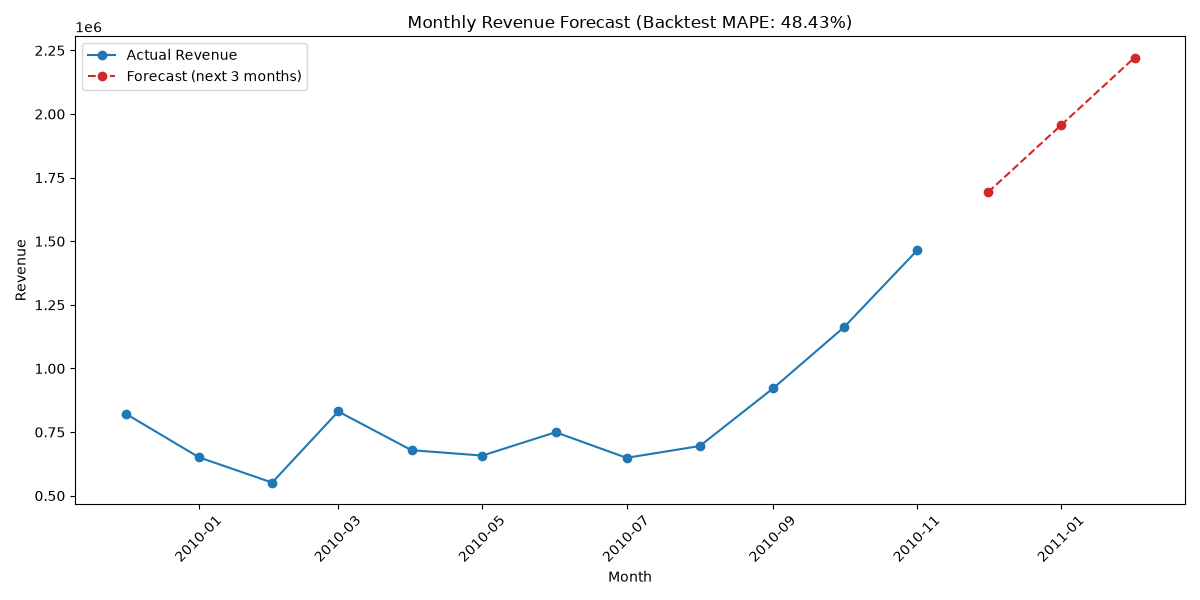

In [14]:
show("revenue_forecast.png")

## 9. Key takeaways

- Revenue is heavily concentrated in the UK and in a small number of top
  products — see `country_analysis` and `product_analysis` above.
- Both segmentation methods agree on the shape of the customer base: a
  small high-value core (Champions/VIP) driving a disproportionate share
  of revenue, and a large at-risk/lost tail.
- Month-1 cohort retention (~20%) is much lower than the naive "repeat
  customer" rate (~67%), because the repeat-customer metric counts any
  second order ever, while cohort retention tracks whether customers stay
  active soon after their first purchase — the more actionable signal for
  a retention campaign.
- The revenue forecast's backtest error is inflated by the dataset's
  single year of history: Nov/Dec carry a real seasonal spike that a
  trend-only model can't learn from just one prior cycle. This is
  reported transparently as a modeling limitation rather than hidden.